# Students' Social Media Habits vs. Productivity
### CS 5100 Final Project
### Authors: Emma Bartnick, Elizabeth Fallat, and Even Laukli

The following dataset was pulled from Kaggle: [Student's Social Media Habits vs. Productivity](https://www.kaggle.com/datasets/racchie/students-social-media-habits-vs-productivity)

Our goal is to preprocess the data, do some exploratory analysis, and try to reproduce some of the results shared in an [existing project posted on Kaggle](https://www.kaggle.com/code/racchie/student-social-media-habits-analyser) using both regression and classification models. 

### Import libraries and read in the dataset
Pandas, numpy, and sklearn libraries are imported in order to process and analysze the dataset.  
We check out the first few rows of the dataset to see what the data looks like in each column.  
We check for missing values in each column. 

In [1]:
# import necessary dependencies 
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/student_phone_addiction_affects_on_productivity(in).csv")
print(df.head())

# columns:
# age, daily_screen_time, social_media_hours, study_hours, sleep_hours, notifications_per_day, focus_score, 
# coffee_per_day,breaks_per_day, night_usage, distraction_score, addiction_level, productivity_score

# check for missing values and NANs
print(df.isna().sum())
print(df.columns[df.isna().any()])

# check how many values there are for addiction levels to encode it
print(df['addiction_level'].unique())

    age  daily_screen_time  social_media_hours  study_hours  sleep_hours  \
0  21.0               5.95                2.81         2.61     7.377325   
1  34.0               3.82                2.33         0.28     7.612689   
2  29.0               3.57                1.64         5.21     6.143298   
3  25.0              10.27                4.37         4.28     4.012145   
4  22.0               2.42                1.60         3.67     6.953253   

   notifications_per_day  focus_score  coffee_per_day  breaks_per_day  \
0             290.254742          NaN             2.0             1.0   
1             270.571074        93.65             1.0             3.0   
2             134.054219       100.00             0.0             5.0   
3             233.019834        94.71             2.0             2.0   
4              19.381791       100.00             0.0             3.0   

   night_usage  distraction_score addiction_level  productivity_score  
0          0.0              7.85

### Encode addiction level and fill missing values
Because the addiction level data is categorical instead of numerical, it needs to be encoded. 
We cannot fill missing values with a median or mean because that would risk having decimal values. So we replace all missing values with the mode, and then we encode the categories to numerical values (0 = Low addiction level, 1 = medium, 2 = high).  
The remaining columns, which were already numerical values, can be handled differently. Missing values are replaced with the median. The median is preffered over mean because it is not skewed by extreme outliers. 

In [2]:
# Fill missing addiction levels with the mode before encoding it
df['addiction_level'] = df['addiction_level'].fillna(df['addiction_level'].mode()[0])
level_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['addiction_level'] = df['addiction_level'].map(level_map)

# Confirm addicition level is numeric now
print(df['addiction_level'].isna().sum())
print(df['addiction_level'].dtype)

# fill rest of the missing values with median
num_cols = df.select_dtypes(include='number').columns
print(df[num_cols].skew())
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


0
int64
age                     -0.021320
daily_screen_time        0.244566
social_media_hours       0.657158
study_hours             -0.041895
sleep_hours             -0.018741
notifications_per_day    0.866399
focus_score             -2.462148
coffee_per_day           0.295010
breaks_per_day           0.469528
night_usage             -0.334850
distraction_score        0.172341
addiction_level         -0.171728
productivity_score       0.297847
dtype: float64


In [3]:
# final check for missing values and NANs
print(df.isna().sum())
print(df.columns[df.isna().any()])

age                      0
daily_screen_time        0
social_media_hours       0
study_hours              0
sleep_hours              0
notifications_per_day    0
focus_score              0
coffee_per_day           0
breaks_per_day           0
night_usage              0
distraction_score        0
addiction_level          0
productivity_score       0
dtype: int64
Index([], dtype='str')


### Check for any duplicate rows

In [4]:
# check for duplicates
print(df.duplicated().sum())
df = df.drop_duplicates()

# look at the productivity score to see mean/min/max/std
df['productivity_score'].describe()

0


count    10000.000000
mean        37.775427
std         27.137700
min        -14.147106
25%         14.860704
50%         36.179357
75%         57.747677
max        112.152143
Name: productivity_score, dtype: float64

### Check out encoded and filled-in data for each column 

In [5]:
# verify columns look good and all the data types are numerical for the models
print(df[num_cols].describe())

df.dtypes

                age  daily_screen_time  social_media_hours   study_hours  \
count  10000.000000       10000.000000        10000.000000  10000.000000   
mean      27.086800           7.076334            4.123600      4.086550   
std        7.074254           2.964752            2.123856      2.271786   
min       15.000000           0.461283            0.000000      0.000000   
25%       21.000000           4.654481            2.479913      2.200073   
50%       27.000000           7.000000            3.771382      4.141210   
75%       33.000000           9.409513            5.430000      5.970000   
max       39.000000          22.372059           11.310630      8.811615   

        sleep_hours  notifications_per_day   focus_score  coffee_per_day  \
count  10000.000000           10000.000000  10000.000000    10000.000000   
mean       6.505929             168.583541     96.253533        1.775098   
std        1.465054              93.679885      7.248072        1.265067   
min        

age                      float64
daily_screen_time        float64
social_media_hours       float64
study_hours              float64
sleep_hours              float64
notifications_per_day    float64
focus_score              float64
coffee_per_day           float64
breaks_per_day           float64
night_usage              float64
distraction_score        float64
addiction_level            int64
productivity_score       float64
dtype: object

In [6]:
# initial correlation between productivity score and all the features 
df.corr()['productivity_score'].sort_values()

social_media_hours      -0.458842
addiction_level         -0.426148
distraction_score       -0.421808
daily_screen_time       -0.356645
night_usage             -0.313989
coffee_per_day          -0.110136
notifications_per_day   -0.075010
age                     -0.000479
sleep_hours              0.192772
breaks_per_day           0.495652
focus_score              0.513559
study_hours              0.686850
productivity_score       1.000000
Name: productivity_score, dtype: float64

### Clip data to remove outliers and invalid values

In [7]:
# Fix physically invalid negative values
# min of -21.352674	notifications per day which isn't possible
# max of 1188.408609 which also seems high and mean is 168
df['notifications_per_day'] = df['notifications_per_day'].clip(lower=0)
df['distraction_score'] = df['distraction_score'].clip(lower=0)

# Cap only the true extreme outliers
cap = df['notifications_per_day'].quantile(0.999)
df['notifications_per_day'] = df['notifications_per_day'].clip(upper=cap)

# output to cleaned csv file
df.to_csv('../data/cleaned_phone_addiction_vs_productivity.csv', index=False)

### Set productivity score as the target column

In [8]:
# split X and y after all cleaning steps
X = df.drop(columns=['productivity_score'])
y = df['productivity_score']

### Split the data into training and testing sets. 
We do this before we scale the data because we do not want the Scaler to learn anything from the test set.  
The data is split to 80% training and 20% testing. 

In [9]:
# Split before scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 12)
X_test: (2000, 12)
y_train: (8000,)
y_test: (2000,)


### Scale the data
The existing data has very different scales for each column, which can lead to bias in a regression algorithm. Therefore, we will use  a StandardScaler to complete z-score standardization of each of the values. 

In [10]:
# Scale features - fit on train only, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])

[[ 1.40291383 -0.03600057 -0.09527556  0.02188797  1.36597916 -0.01825109
   0.51484854 -0.33919106  0.57576828  0.82331789 -0.01778824 -0.23285004]
 [ 0.12941892 -1.42409955 -1.02679011  1.70699423  0.46230784  0.3227068
   0.51484854 -0.61548943  1.08495158 -1.21459768 -1.04461739 -1.74363697]
 [-1.28557542 -1.36312557 -0.79168329  0.02575669  0.8803797  -0.19500481
   0.51484854 -0.61548943 -0.47159328 -1.21459768 -1.12618793 -0.23285004]
 [ 1.40291383 -0.39516481 -0.75788637  1.10654913 -0.32650923 -0.21145822
   0.51484854  0.17322186  0.68114362 -1.21459768 -1.43915245 -0.23285004]
 [ 0.55391722 -1.00027842 -0.08800902  0.55586632 -1.13021649 -1.04948035
   0.13614349  1.25404558  1.40871178 -1.21459768 -0.78277448 -0.23285004]]


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression, Ridge, lasso_path
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

sns.set_theme(style='whitegrid')
feature_names = list(X_train.columns)
print('features:', len(feature_names))

features: 12


### Examine the distribution for our target value: Productivity score

In visualizing the distribution, we prioritized identifying the median bin, which contains imputed values for the missing entries in the dataset. 

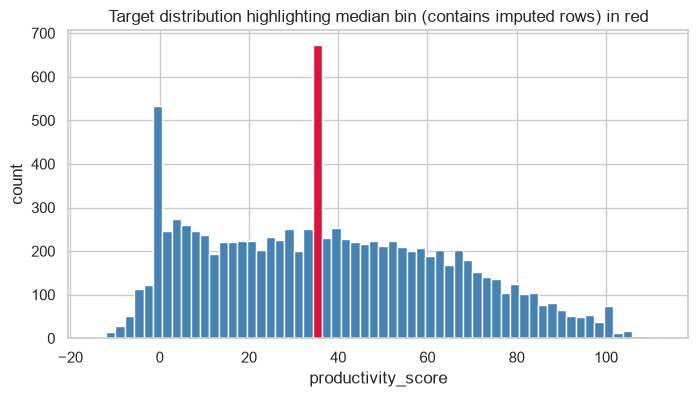

median: 36.179
rows precisely on the median (including replaced missing values): 464


In [12]:
# calculate the median productivity score 
median_val = df['productivity_score'].median()

# build a histogram plot that shows overall distribution of productivity scores and highlights the bin containing the median
fig, ax = plt.subplots(figsize=(8, 4)) # size of plot
# create 60 bins w/ standard coloring of blue bin w/ white edges
counts, bin_edges, patches = ax.hist(df['productivity_score'], bins=60, color='steelblue', edgecolor='white')

# identify the edge values for each bin and find the bin that contains the median
for left, right, patch in zip(bin_edges[:-1], bin_edges[1:], patches):
    if left <= median_val < right:
        patch.set_facecolor('crimson') # make median bin red

# add titles for graph and axes
ax.set_xlabel('productivity_score')
ax.set_ylabel('count') # how many values are in that bin
ax.set_title('Target distribution highlighting median bin (contains imputed rows) in red')
# show the plot
plt.show()

# print information about the median
print('median:', round(median_val, 3)) 
print('rows precisely on the median (including replaced missing values):', int((df['productivity_score'] == median_val).sum()))

### Looking at features before and after scaling

#### Before scaling: 

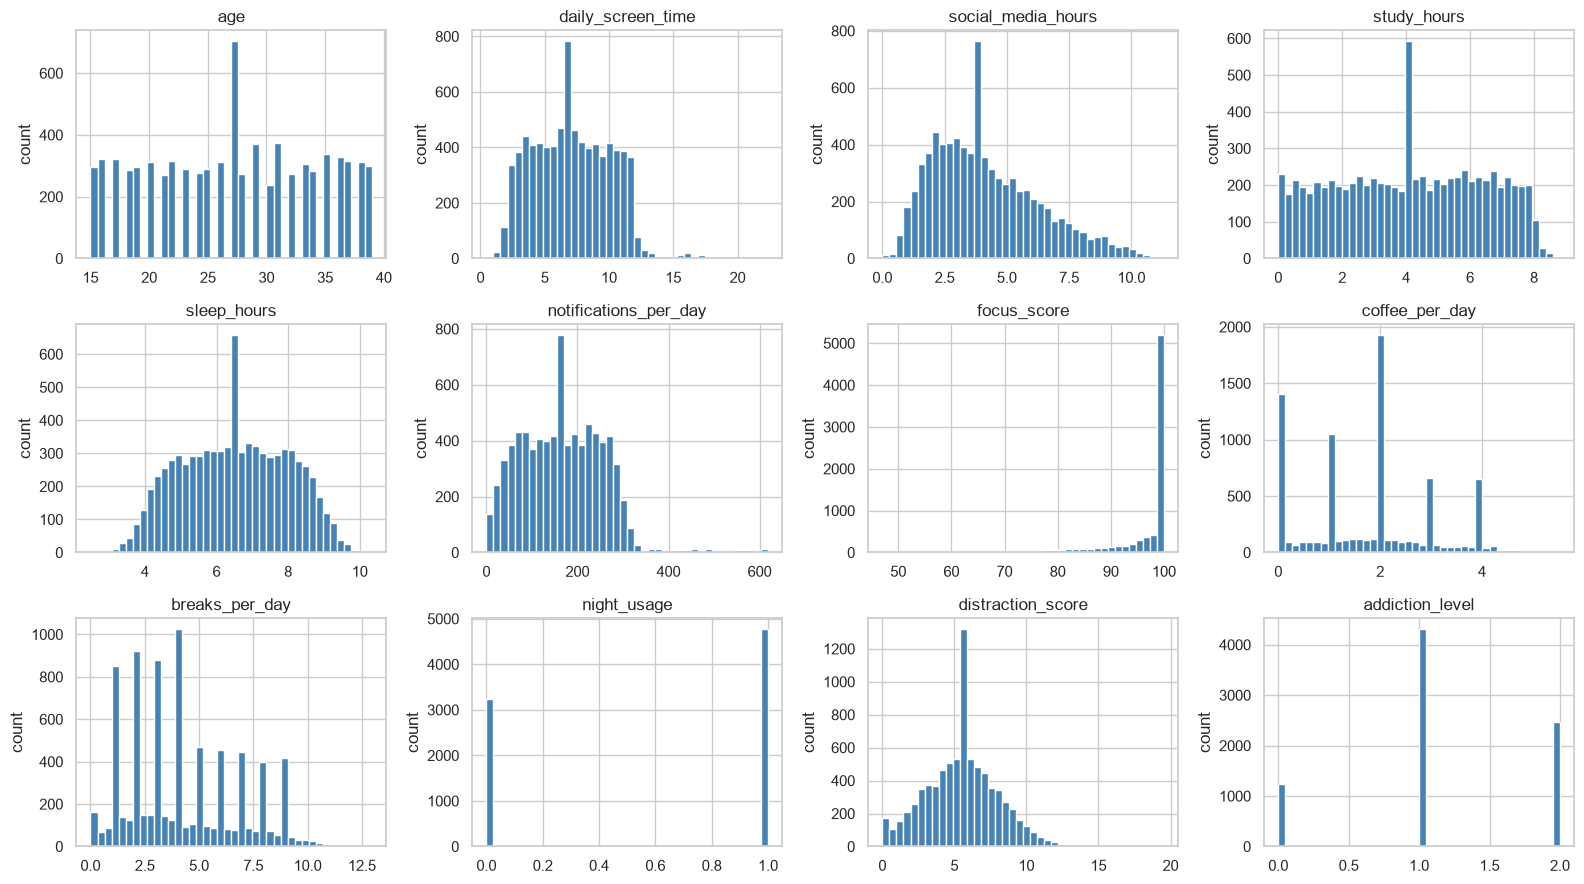

In [13]:
# create 12 histograms showing the distribution of each feature before scaling
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, col in zip(axes.ravel(), feature_names):
    # pull from pre-scaling training data
    ax.hist(X_train[col], bins=40, color='steelblue')
    ax.set_title(col)
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

#### After Scaling:
You can see that the values on the x-axes are much less varied, but the general look of the distributions has not changed. 

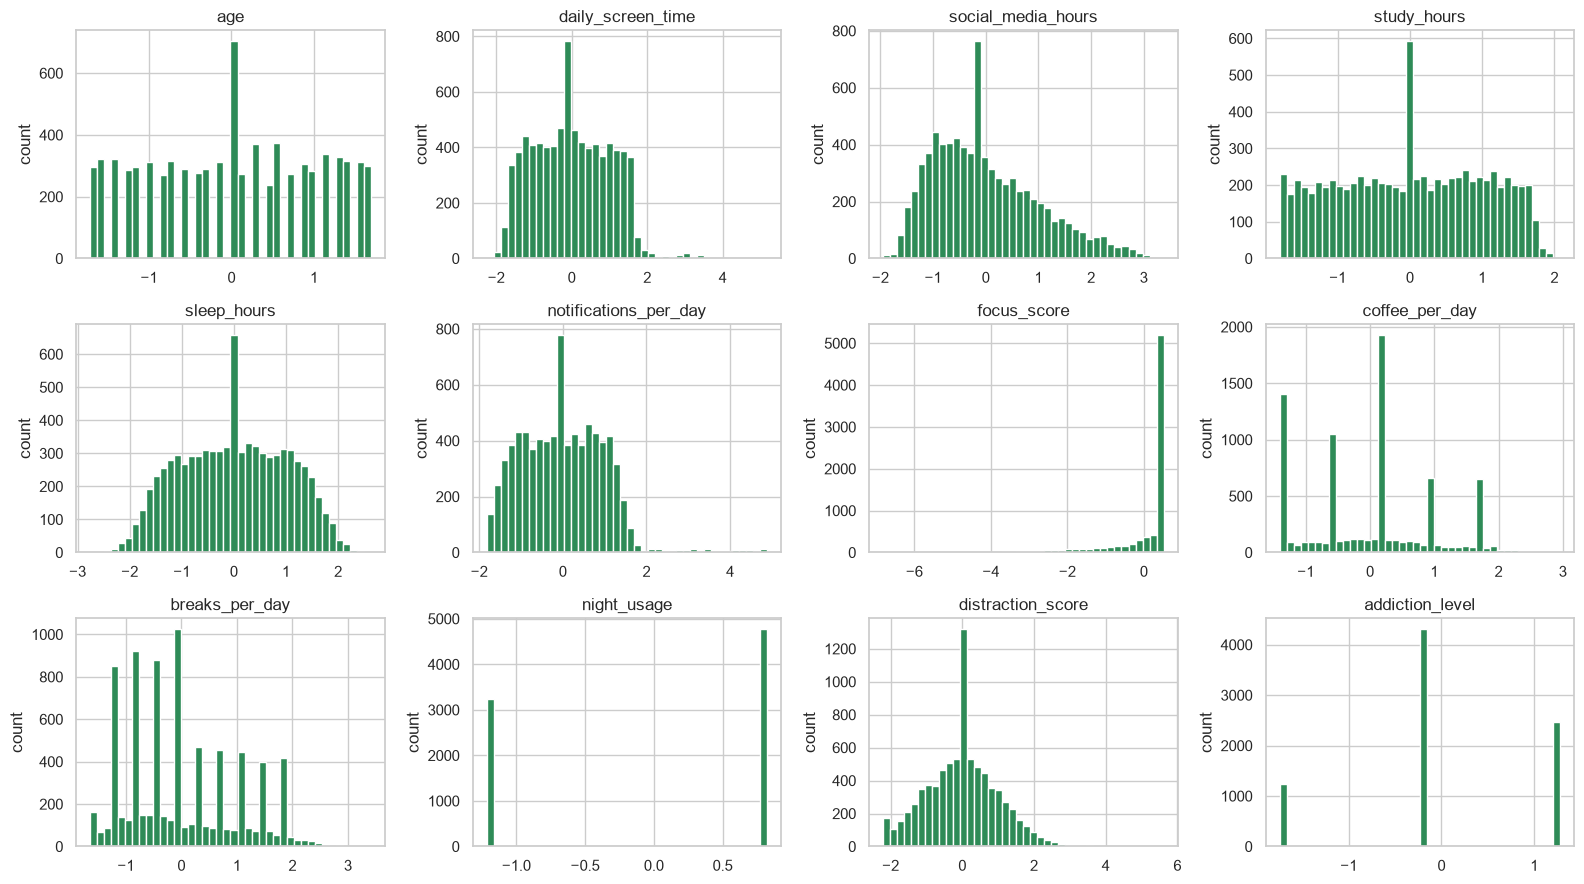

In [14]:
# create 12 histograms showing the distribution of each feature AFTER scaling
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for i, (ax, col) in enumerate(zip(axes.ravel(), feature_names)):
    # pull from scaled training set
    ax.hist(X_train_scaled[:, i], bins=40, color='seagreen')
    ax.set_title(col)
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

### Correlation Heatmap

In a correlation heatmap, we can explore the question of which features have a strong positive or negative correlation to one another. 

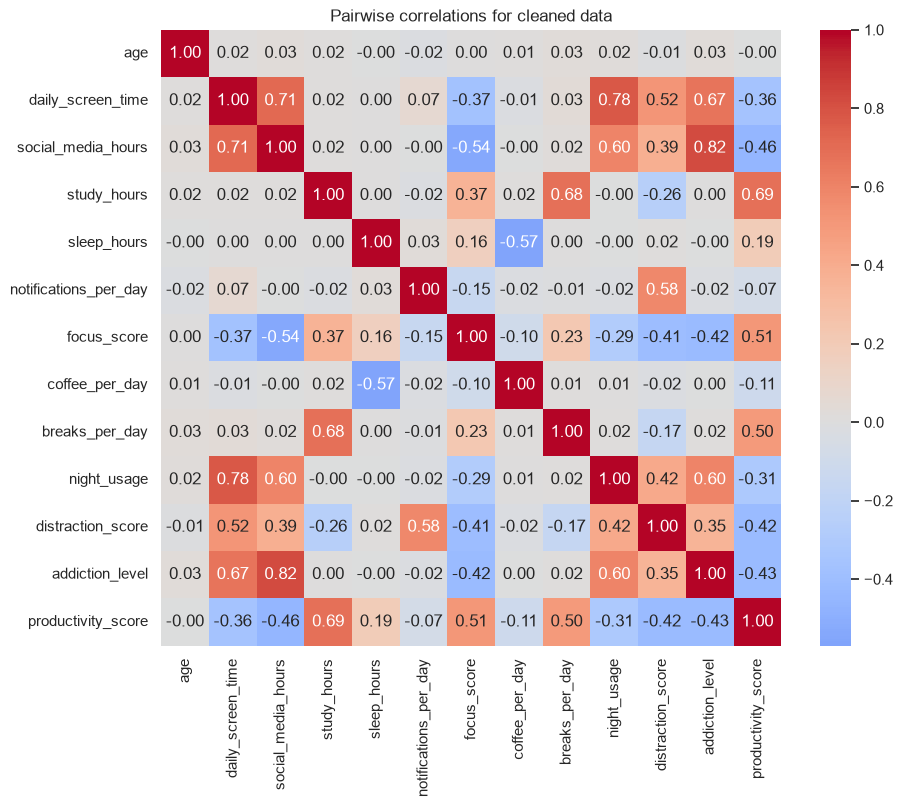

In [15]:
# get correlation values across the dataframe
corr = df.corr()

# build a heatmap showing correlation values
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Pairwise correlations for cleaned data')
plt.show()

Note strong correlations: 

1. Positive correlation between addiction level and daily screen time (+0.67) as well as between addiction level and social media hours (+0.82) -- may indicate that these are key determinants of addiction level
2. Positive correlation between Productivity score and study hours (+0.69) -- may indicate that study hours are a key determinant of productivity score
3. Positive correlation between social media hours and daily screen time (+0.71). This makes logical sense because more time on social media will contribute to more screen time. 
4. Positive correlation between study hours and breaks per day (+0.68)

### Build an evaluation function 
We can plug in any model (pipeline) with the training and testing data to run the model and evaluate the results. 

In [16]:
# Evaluation Helper with a results list to compare as we add models
def evaluate(name, pipe, X_train, y_train, X_test, y_test):
    # fit, prediction, testing and rmse
    pipe.fit(X_train, y_train) 
    pred_train = pipe.predict(X_train) 
    pred_test = pipe.predict(X_test) 
    # five-fold cross evaluation resulting in calculation of the negative root mean squared error
    cv_rmse = -cross_val_score(pipe, X_train, y_train, cv=5,
                               scoring='neg_root_mean_squared_error')

    # sklearns metrics module 
    return {
        'model': name,
        'train_rmse': np.sqrt(mean_squared_error(y_train, pred_train)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, pred_test)),
        'train_mae': mean_absolute_error(y_train, pred_train),
        'test_mae': mean_absolute_error(y_test, pred_test),
        'train_r2': r2_score(y_train, pred_train),
        'test_r2': r2_score(y_test, pred_test),
        'cv_rmse_mean': cv_rmse.mean(),
        'cv_rmse_std': cv_rmse.std(),
    }

# to store results from each model
results = []

### Ordinary Least Squares for a baseline comparison linear regression model

In [17]:
# build the ordinary least squares model
ols = Pipeline([
    # should not need to scale a second time. 
    #('scaler', StandardScaler()), 
    ('model', LinearRegression()),
])
# run and evaluate the OLS model. Add the results to our results array.
# August 4 update: replace X_train and X_test with X_train_scaled and X_test_scaled
results.append(evaluate('ols', ols, X_train_scaled, y_train, X_test_scaled, y_test))

# print the results just added to results array (-1 = last item in list)
print(results[-1])

{'model': 'ols', 'train_rmse': np.float64(13.695346438948812), 'test_rmse': np.float64(13.781063000173999), 'train_mae': 10.679228028953657, 'test_mae': 10.7246917579853, 'train_r2': 0.745744146896484, 'test_r2': 0.7402094477111819, 'cv_rmse_mean': np.float64(13.720273983469909), 'cv_rmse_std': np.float64(0.22215419622783075)}


### Random Forest linear regression

In order to compare to the existing published report for this dataset, we wanted to also complete a random forest regression. Our goal here is to see if we get different, or even better results with our different approach to data cleaning and set-up. 

In [18]:
# build the random forest model
rf = Pipeline([
    # ('scaler', StandardScaler())
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1)), # n_jobs = -1 means scikit learn should use all available CPU cores
])

# run the model, evaluate, and add the results to the array
results.append(evaluate('random_forest', rf, X_train_scaled, y_train, X_test_scaled, y_test))

# print the results
print(results[-1])

{'model': 'random_forest', 'train_rmse': np.float64(4.706696157241854), 'test_rmse': np.float64(12.86802266609107), 'train_mae': 3.5818031062927265, 'test_mae': 9.88211132381773, 'train_r2': 0.9699698680598664, 'test_r2': 0.7734930399723543, 'cv_rmse_mean': np.float64(12.81447138213465), 'cv_rmse_std': np.float64(0.17013712092971678)}


### Examine and compare results from our two regression models

In [19]:
#Comparison (move down as we add more models)
comparison = pd.DataFrame(results).set_index('model').round(3)
comparison


,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2,cv_rmse_mean,cv_rmse_std
model,,,,,,,,
ols,13.695,13.781,10.679,10.725,0.746,0.740,13.720,0.222
random_forest,4.707,12.868,3.582,9.882,0.970,0.773,12.814,0.170


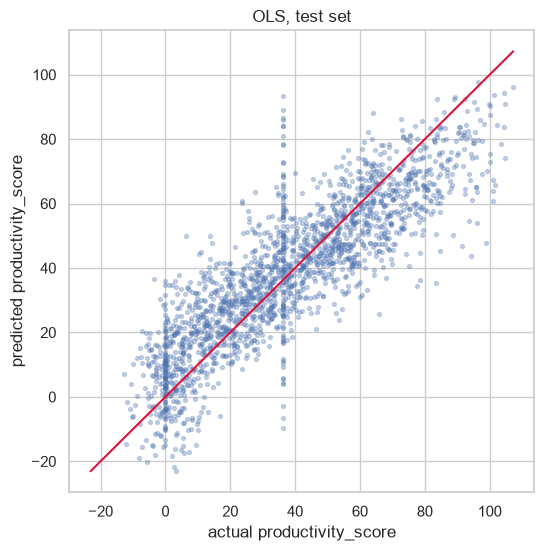

In [20]:
# Build a graph showing predicted vs actual Productivity scores for the OLS Model
# we need to run the ols model again because the evaluate() function did not save the predictions from the last run
pred_test_ols = ols.predict(X_test_scaled)

# create the scatter plot where x-axis = the target value and y-axis = predicted value
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred_test_ols, s=8, alpha=0.3)

# create a red line from min to max values where x = y (perfect predictions would fall on this line)
lims = [min(y_test.min(), pred_test_ols.min()), max(y_test.max(), pred_test_ols.max())]
ax.plot(lims, lims, color='crimson')

# label axes and create graph title 
ax.set_xlabel('actual productivity_score')
ax.set_ylabel('predicted productivity_score')
ax.set_title('OLS, test set')
plt.show()

In this graph, we can see that the correlation between the plotted points and the perfect prediction line is good, but not perfect. One interesting thing to note is the large range of predicted values when the actual productivity score is at the median value. This is very likely the result of all of the input median values when a productivity score was missing. 

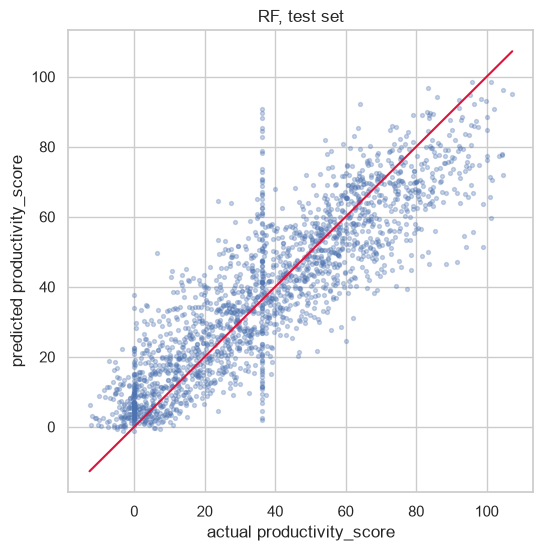

In [21]:
pred_test_rf = rf.predict(X_test_scaled)

# create the scatter plot where x-axis = the target value and y-axis = predicted value
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred_test_rf, s=8, alpha=0.3)

# create a red line from min to max values where x = y (perfect predictions would fall on this line)
lims = [min(y_test.min(), pred_test_rf.min()), max(y_test.max(), pred_test_rf.max())]
ax.plot(lims, lims, color='crimson')

# label axes and create graph title 
ax.set_xlabel('actual productivity_score')
ax.set_ylabel('predicted productivity_score')
ax.set_title('RF, test set')
plt.show()

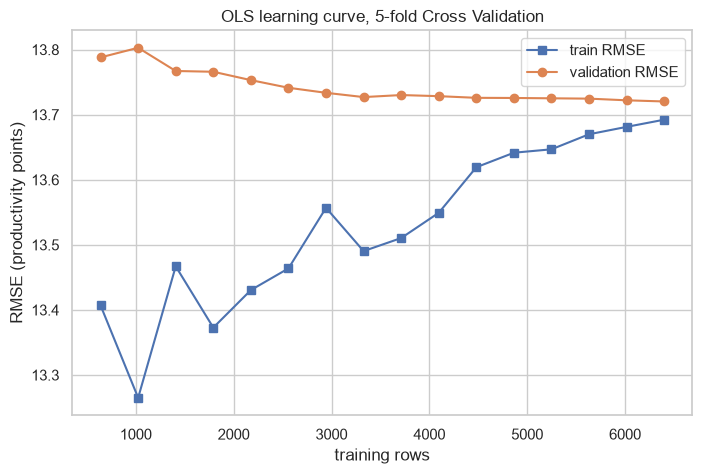

In [22]:
# Learning curve for OLS
train_sizes, train_scores, val_scores = learning_curve(
    ols, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1, 16),
    scoring='neg_root_mean_squared_error', n_jobs=-1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, -train_scores.mean(axis=1), marker='s',label='train RMSE')
ax.plot(train_sizes, -val_scores.mean(axis=1), marker='o', label='validation RMSE')
ax.set_xlabel('training rows')
ax.set_ylabel('RMSE (productivity points)')
ax.set_title('OLS learning curve, 5-fold Cross Validation')
ax.legend()
plt.show()

Since the training and validation curves seem to converge past 6000 rows, we can assume that more data would not improve the model performance. The data quality or model form are the limiting factors for the ordinary least squares regression. 

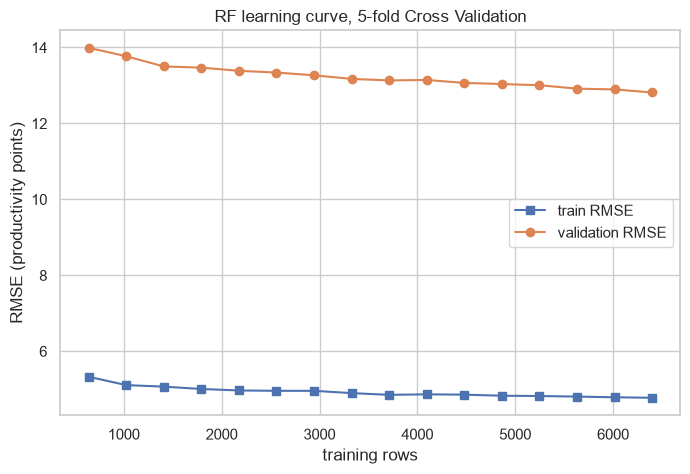

In [23]:
# Learning curve for RF
train_sizes, train_scores, val_scores = learning_curve(
    rf, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1, 16),
    scoring='neg_root_mean_squared_error', n_jobs=-1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, -train_scores.mean(axis=1), marker='s',label='train RMSE')
ax.plot(train_sizes, -val_scores.mean(axis=1), marker='o', label='validation RMSE')
ax.set_xlabel('training rows')
ax.set_ylabel('RMSE (productivity points)')
ax.set_title('RF learning curve, 5-fold Cross Validation')
ax.legend()
plt.show()

In [24]:
# compare RMSE to total range of productivity scores
print(y_train.min())
print(y_train.max())
print(y_train.mean())
print(y_train.std())

print(y_test.min())
print(y_test.max())

-14.14710565
112.152143
37.844643477137495
27.162184077439445
-12.68721111
107.2675253


While RMSE values of approximately 13 may seem large, the target variable ranges from approximately -14 to 112, giving it a total range of about 126 productivity-score points. 

Do the residuals (errors) change depending on any individual feature values? 

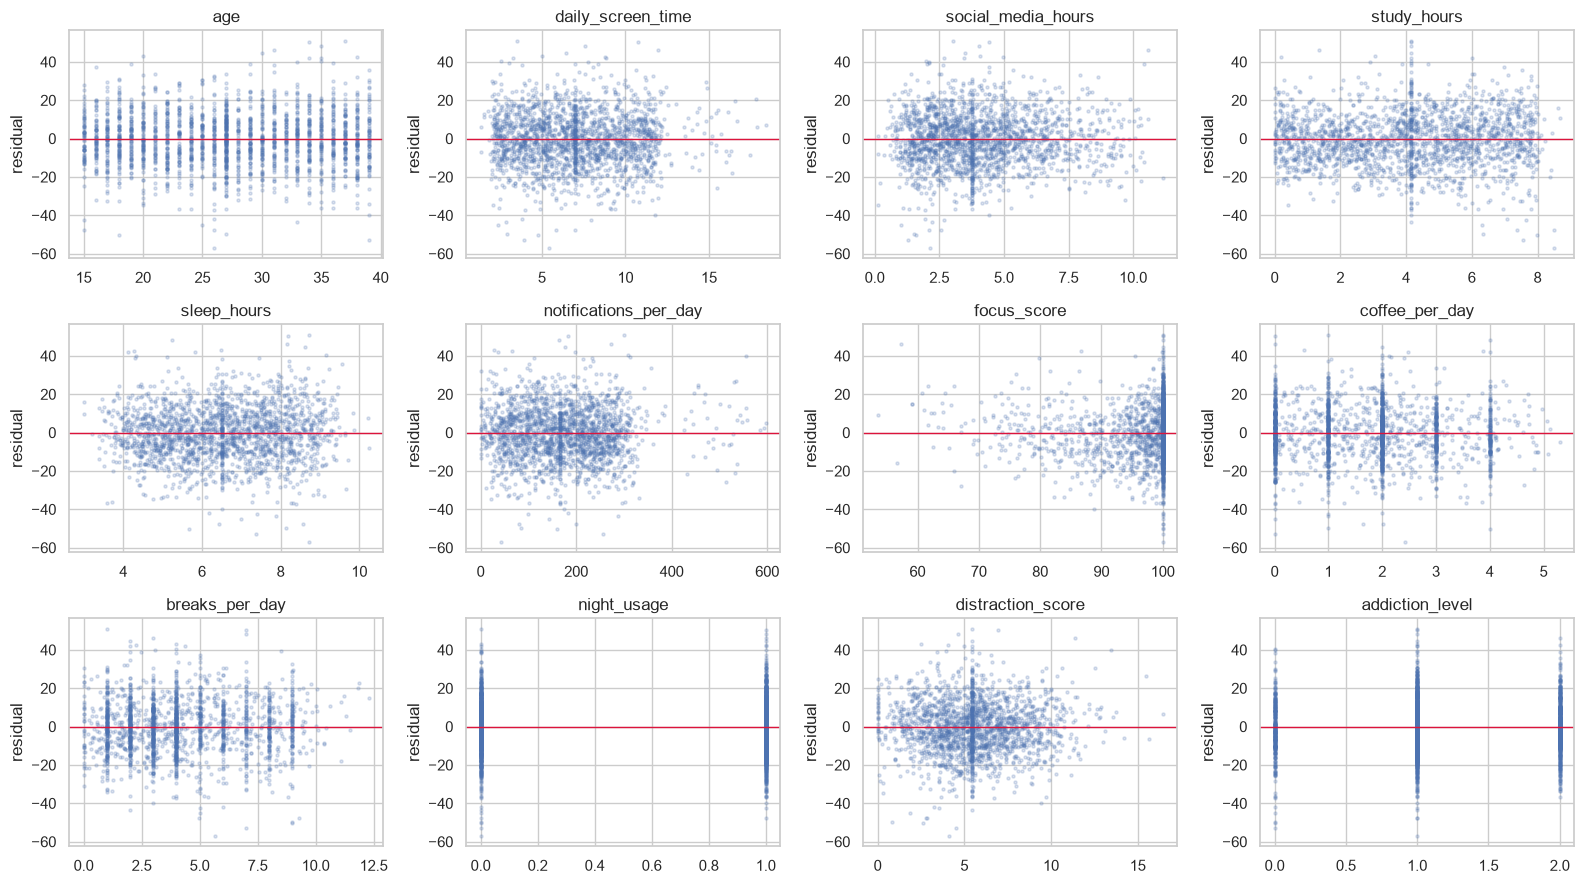

In [25]:
# Plotting residuals against each feature
# residuals = actual - predicted values
residuals = y_test - pred_test_ols

# plot for all 12 features 
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, col in zip(axes.ravel(), feature_names):
    ax.scatter(X_test[col], residuals, s=5, alpha=0.2) # note: using unscaled data here because it is still in dataframe form
    ax.axhline(0, color='crimson', linewidth=1)
    ax.set_title(col)
    ax.set_ylabel('residual')
plt.tight_layout()
plt.show()

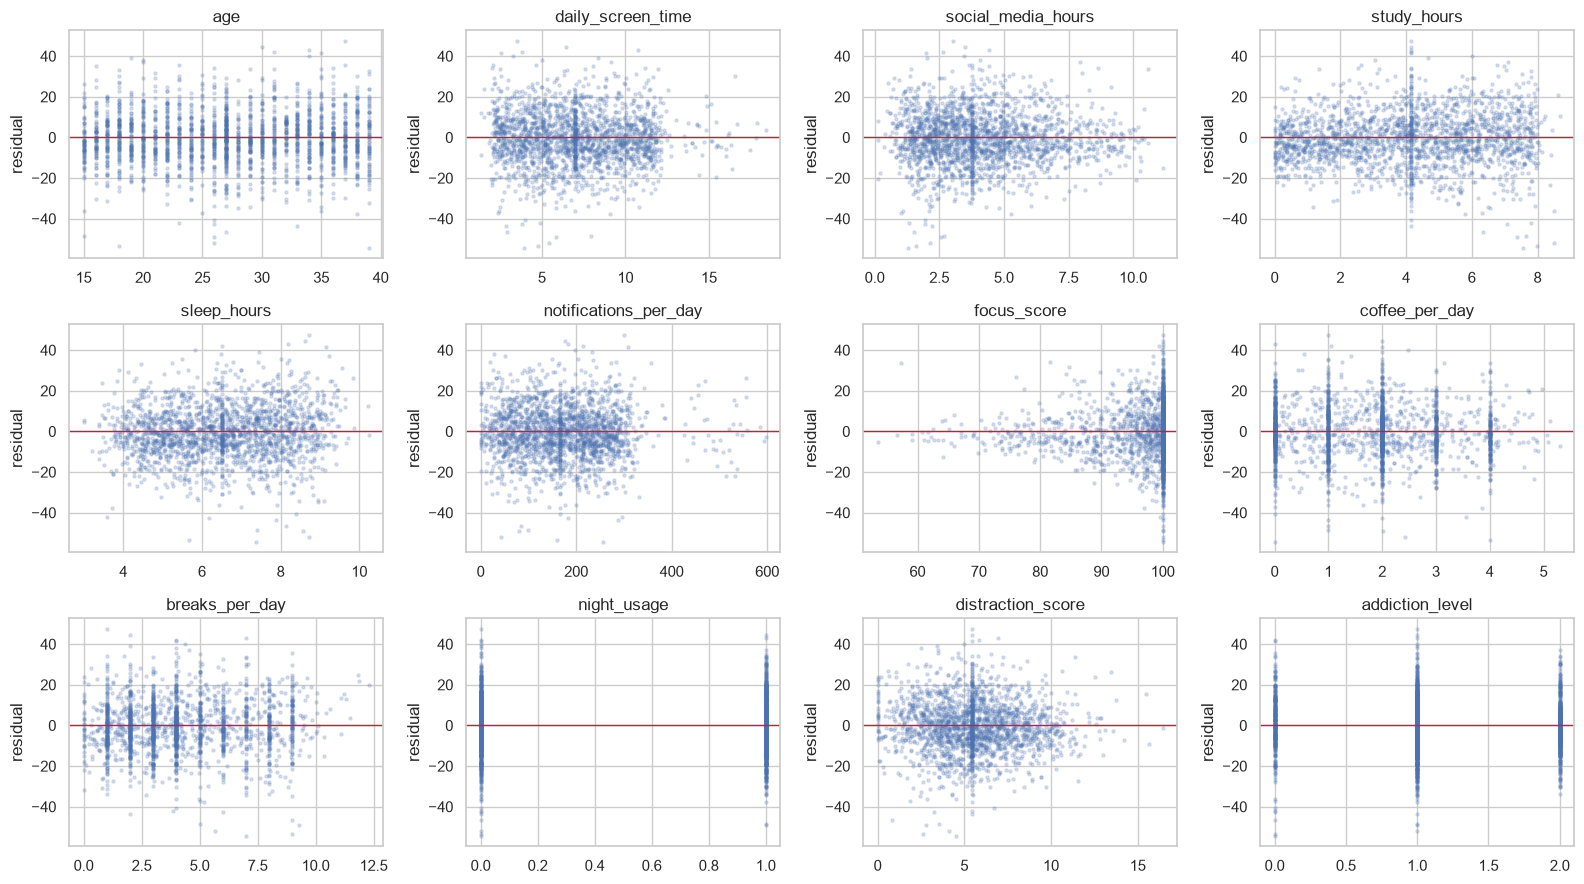

In [26]:
residuals = y_test - pred_test_rf

# plot for all 12 features 
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, col in zip(axes.ravel(), feature_names):
    ax.scatter(X_test[col], residuals, s=5, alpha=0.2) # note: using unscaled data here because it is still in dataframe form
    ax.axhline(0, color='crimson', linewidth=1)
    ax.set_title(col)
    ax.set_ylabel('residual')
plt.tight_layout()
plt.show()

Note: Focus score stands out as being skewed with the greatest amount of data but also the greatest amount of error on the far right (focus score = 100). 

In [27]:
# examine focus score data
print(X_train['focus_score'].describe())

count    8000.000000
mean       96.275606
std         7.234413
min        47.005155
25%        96.000915
50%       100.000000
75%       100.000000
max       100.000000
Name: focus_score, dtype: float64


Since the vast majority of the data points are in the same range as where the greatest errors are occurring, it is likely not outliers that are the problem. 

We will try removing focus score all together to see if results improve. 

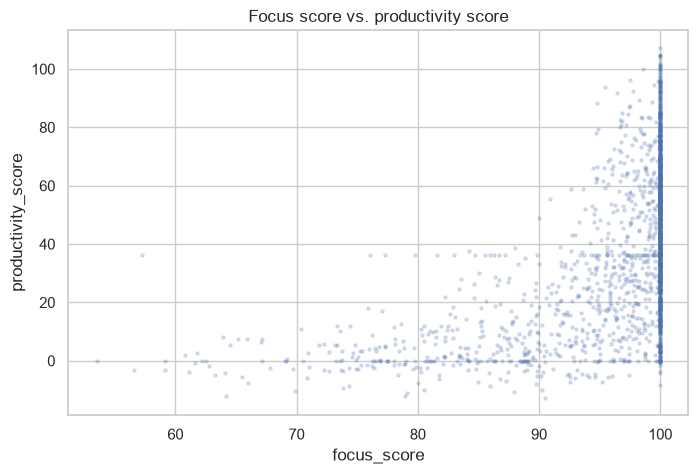

In [28]:
# check for a clear relationship between focus score and productivity score
plt.figure(figsize=(8, 5))
plt.scatter(
    X_test['focus_score'],
    y_test,
    s=5,
    alpha=0.2
)
plt.xlabel('focus_score')
plt.ylabel('productivity_score')
plt.title('Focus score vs. productivity score')
plt.show()

We can see here that there is not a clear linear relationship between focus score and productivity score. While the maximum observed productivity score does increase with the focus score, the minimum observed score remains the same. Therefore, the range of possible focus scores increases greatly as focus score increases. 

We will try removing the focus score from the dataset to see if it results in any better results. 

In [29]:
# create list of feature names (was not made earlier) 
feature_names = df.columns.drop('productivity_score').tolist()

# make new list w/o focus score
feature_names_no_focus = [
    col for col in feature_names
    if col != 'focus_score'
]

# drop focus score from training and testing feature data
X_train_no_focus = X_train.drop(columns=['focus_score'])
X_test_no_focus = X_test.drop(columns=['focus_score'])

# create a new scaler
scaler_no_focus = StandardScaler()

# scale new training set (without focus score)
X_train_no_focus_scaled = pd.DataFrame(
    scaler_no_focus.fit_transform(X_train_no_focus),
    columns=X_train_no_focus.columns,
    index=X_train_no_focus.index
)

# scale new test set (without focus score)
X_test_no_focus_scaled = pd.DataFrame(
    scaler_no_focus.transform(X_test_no_focus),
    columns=X_test_no_focus.columns,
    index=X_test_no_focus.index
)

In [30]:
# run the ordinary least squares regression again to see if results improve. 
ols_no_focus = LinearRegression()

# add results to the existing list
results.append(
    evaluate(
        'ols_no_focus',
        ols_no_focus,
        X_train_no_focus_scaled,
        y_train,
        X_test_no_focus_scaled,
        y_test
    )
)

# print results
print(results[-1])

{'model': 'ols_no_focus', 'train_rmse': np.float64(13.749369880871065), 'test_rmse': np.float64(13.821559093674253), 'train_mae': 10.758919275172822, 'test_mae': 10.793271496374908, 'train_r2': 0.7437342864176952, 'test_r2': 0.7386803987674204, 'cv_rmse_mean': np.float64(13.770623081227715), 'cv_rmse_std': np.float64(0.2219380615544966)}


In [31]:
# run the random forest regression again to see if results improve. 
rf_no_focus = RandomForestRegressor()

# add results to the existing list
results.append(
    evaluate(
        'rf_no_focus',
        rf_no_focus,
        X_train_no_focus_scaled,
        y_train,
        X_test_no_focus_scaled,
        y_test
    )
)

# print results
print(results[-1])

{'model': 'rf_no_focus', 'train_rmse': np.float64(4.775795626721686), 'test_rmse': np.float64(12.848646592014191), 'train_mae': 3.6254158086796338, 'test_mae': 9.924756332464625, 'train_r2': 0.9690816448811951, 'test_r2': 0.7741746538476642, 'cv_rmse_mean': np.float64(12.851206482678204), 'cv_rmse_std': np.float64(0.19060162835721398)}


In [32]:
# show comparison of all regression models
comparison = pd.DataFrame(results).set_index('model').round(3)
comparison

,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2,cv_rmse_mean,cv_rmse_std
model,,,,,,,,
ols,13.695,13.781,10.679,10.725,0.746,0.740,13.720,0.222
random_forest,4.707,12.868,3.582,9.882,0.970,0.773,12.814,0.170
ols_no_focus,13.749,13.822,10.759,10.793,0.744,0.739,13.771,0.222
rf_no_focus,4.776,12.849,3.625,9.925,0.969,0.774,12.851,0.191


Note: Results are not improved by removing focus score. We should stick with the model that includes the focus score feature. 

## Random Forest Classifier Model
### Classify continuous productivity_score into three bands

Since the productivity score is a continuous target we need to classify it into bands for the classifier model to be able to work. this is where our notebook diverges from the [SM habits Analyzer](https://www.kaggle.com/code/racchie/student-social-media-habits-analyser) notebook. For some reason they chose to switch the target to `addiction_level` in their analisys and drop `addiction_level, productivity_score,distraction_score` before fitting the classifier so comparison between our analysis here becomes more difficult.

The bins are computed on y_train only and then applied to y_test. Using the full target to
choose the boundaries would leak test information into the label definition.

In [33]:
# Imports for classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             ConfusionMatrixDisplay)


In [34]:
# defining the cutoffs 
low_cut, high_cut = y_train.quantile([1/3, 2/3])
class_names = ['Low', 'Medium', 'High']

# helper to segment target into bins 
def to_band(scores):
    return pd.cut(scores, bins=[-np.inf, low_cut, high_cut, np.inf], labels=class_names)

# cut on train and test separately
y_train_cls = to_band(y_train)
y_test_cls = to_band(y_test)

# checking that bins are roughly equal
print('cut points:', round(low_cut, 2), round(high_cut, 2))
print('train class counts:')
print(y_train_cls.value_counts()[class_names])
print('test class counts:')
print(y_test_cls.value_counts()[class_names])

cut points: 22.99 49.21
train class counts:
productivity_score
Low       2667
Medium    2666
High      2667
Name: count, dtype: int64
test class counts:
productivity_score
Low       671
Medium    638
High      691
Name: count, dtype: int64


## Evaluation Helper
similar to the one for regressions above but has acc, f1, and cross fold validation

In [35]:
def evaluate_clf(name, pipe, X_train, y_train_cls, X_test, y_test_cls):
    pipe.fit(X_train, y_train_cls)
    pred_train = pipe.predict(X_train)
    pred_test = pipe.predict(X_test)
    cv_f1 = cross_val_score(pipe, X_train, y_train_cls, cv=5, scoring='f1_macro')
    return {
        'model': name,
        'train_acc': accuracy_score(y_train_cls, pred_train),
        'test_acc': accuracy_score(y_test_cls, pred_test),
        'train_f1_macro': f1_score(y_train_cls, pred_train, average='macro'),
        'test_f1_macro': f1_score(y_test_cls, pred_test, average='macro'),
        'cv_f1_mean': cv_f1.mean(),
        'cv_f1_std': cv_f1.std(),
    }

clf_results = []

### Random Forest Classifiers

We fit two classifier models, one with a limited depth and one unconstrained to see how much we lose with the constrained, shallow classifier model. 

In [36]:
# Shallow Classifier
rf_shallow = Pipeline([
    ('model', RandomForestClassifier(max_depth=5, n_estimators=300,
                                     random_state=42, n_jobs=-1)),
])

# print results
clf_results.append(evaluate_clf('rf_shallow_d5', rf_shallow, X_train, y_train_cls, X_test, y_test_cls))
print(clf_results[-1])

{'model': 'rf_shallow_d5', 'train_acc': 0.747375, 'test_acc': 0.698, 'train_f1_macro': 0.7476753627470756, 'test_f1_macro': 0.6980710744921271, 'cv_f1_mean': np.float64(0.7277522302678333), 'cv_f1_std': np.float64(0.004313237093598222)}


In [37]:
# Full Depth Classifier
rf_full = Pipeline([
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1)),
]) 

#print results
clf_results.append(evaluate_clf('rf_full_depth', rf_full, X_train, y_train_cls, X_test, y_test_cls))
print(clf_results[-1])

{'model': 'rf_full_depth', 'train_acc': 1.0, 'test_acc': 0.747, 'train_f1_macro': 1.0, 'test_f1_macro': 0.7450277027424406, 'cv_f1_mean': np.float64(0.7520322326710851), 'cv_f1_std': np.float64(0.008291908354852745)}


In [38]:
# Comparison
clf_comparison = pd.DataFrame(clf_results).set_index('model').round(3)
clf_comparison

,train_acc,test_acc,train_f1_macro,test_f1_macro,cv_f1_mean,cv_f1_std
model,,,,,,
rf_shallow_d5,0.747,0.698,0.748,0.698,0.728,0.004
rf_full_depth,1.000,0.747,1.000,0.745,0.752,0.008


In [39]:
# showing precision, recall and f1 for each class using sklearn's classifcation_report
pred_shallow = rf_shallow.predict(X_test)
pred_full = rf_full.predict(X_test)

print('shallow forest, depth 5')
print(classification_report(y_test_cls, pred_shallow, digits=3))
print('unconstrained forest')
print(classification_report(y_test_cls, pred_full, digits=3))

shallow forest, depth 5
              precision    recall  f1-score   support

        High      0.762     0.754     0.758       691
         Low      0.812     0.756     0.783       671
      Medium      0.532     0.577     0.553       638

    accuracy                          0.698      2000
   macro avg      0.702     0.695     0.698      2000
weighted avg      0.705     0.698     0.701      2000

unconstrained forest
              precision    recall  f1-score   support

        High      0.801     0.818     0.809       691
         Low      0.834     0.796     0.815       671
      Medium      0.603     0.619     0.611       638

    accuracy                          0.747      2000
   macro avg      0.746     0.744     0.745      2000
weighted avg      0.749     0.747     0.748      2000



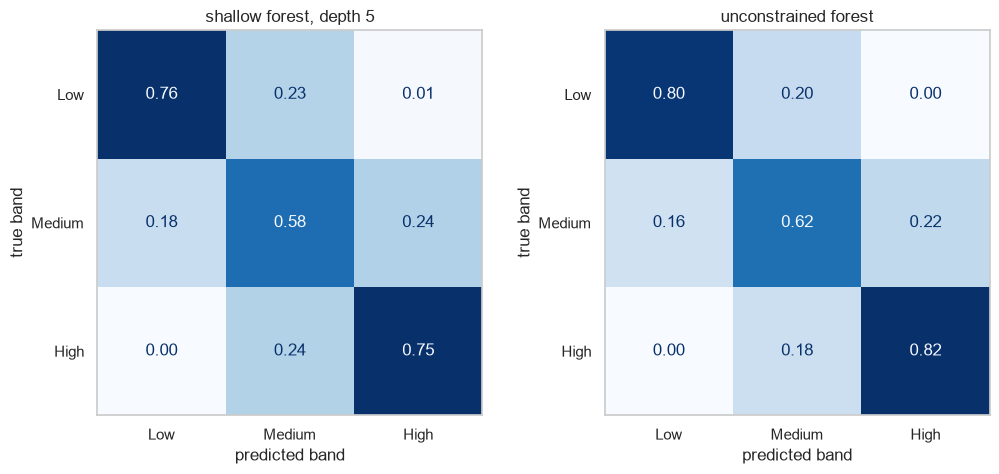

In [40]:
# Confusion Matrix for both classifiers 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, title in zip(axes, [pred_shallow, pred_full],
                            ['shallow forest, depth 5', 'unconstrained forest']):
    ConfusionMatrixDisplay.from_predictions(
        y_test_cls, preds, labels=class_names, normalize='true',
        cmap='Blues', values_format='.2f', colorbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('predicted band')
    ax.set_ylabel('true band')
    ax.grid(False)
plt.show()

The shallow forest does not perform as well as the full depth one (as expected) in this notebook we cap the shallow forest at 5 levels but increasing it above 10 seemed to approach the accuracy of the unconstrained forest

In [41]:
results.clear()

In [60]:
# DEMO: Predict productivity for a new person

people = [
    {
        'age': 21,
        'daily_screen_time': 12,
        'social_media_hours': 2.5,
        'study_hours': 9,
        'sleep_hours': 6.5,
        'notifications_per_day': 60,
        'focus_score': 60,
        'coffee_per_day': 0,
        'breaks_per_day': 10,
        'night_usage': 1,
        'distraction_score': 10,
        'addiction_level': 1,  
    },
    {
        'age': 31,
        'daily_screen_time': 8.5,
        'social_media_hours': 1.83,
        'study_hours': 4,
        'sleep_hours': 8.5,
        'notifications_per_day': 30,
        'focus_score': 70,
        'coffee_per_day': 1,
        'breaks_per_day': 5,
        'night_usage': 1,
        'distraction_score': 10,
        'addiction_level': 1,
    },
    {
        'age': 28,
        'daily_screen_time': 4.5,
        'social_media_hours':2,
        'study_hours': 6,
        'sleep_hours': 7.5,
        'notifications_per_day': 15,
        'focus_score': 50,
        'coffee_per_day': 1,
        'breaks_per_day': 2,
        'night_usage': 1,
        'distraction_score': 10,
        'addiction_level': 1,
    },
]

new_df = pd.DataFrame(people)[list(X_train.columns)]
new_scaled = scaler.transform(new_df)

# Predict productivity_level
predicted_bands = rf_full.predict(new_scaled)

# Print a result for each person
for i, band in enumerate(predicted_bands, start=1):
    is_productive = "Yes" if band in ("Medium", "High") else "No"
    print(f"Person {i} predicted productivity level: {band} | Is productive? {is_productive}")

Person 1 predicted productivity level: Medium | Is productive? Yes
Person 2 predicted productivity level: Low | Is productive? No
Person 3 predicted productivity level: Medium | Is productive? Yes


c:\Users\emfal\CS5100-Final-Project\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
